#### 目标：
#### 1.订单表的长度，shape，columns
#### 2.统计菜名的平均价格（amounts）
#### 3.什么菜最受欢迎
#### 4.哪个订单ID点的菜最多
#### ...

In [22]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
plt.rcParams['font.sans-serif'] = 'SimHei' #设置中文显示
%matplotlib inline

# 1.加载数据
data1 = pd.read_excel('meal_order_detail.xlsx',sheet_name='meal_order_detail1')
data2 = pd.read_excel('meal_order_detail.xlsx',sheet_name='meal_order_detail2')
data3 = pd.read_excel('meal_order_detail.xlsx',sheet_name='meal_order_detail3')

# 2.数据预处理（合并数据，NA值等处理），分析数据
data = pd.concat([data1,data2,data3],axis=0) #按行拼接数据
data.dropna(axis=1,inplace=True) #按列删除空值，并且修改源数据
data.info() #查看数据信息

<class 'pandas.core.frame.DataFrame'>
Index: 10037 entries, 0 to 3610
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   detail_id         10037 non-null  int64         
 1   order_id          10037 non-null  int64         
 2   dishes_id         10037 non-null  int64         
 3   dishes_name       10037 non-null  object        
 4   itemis_add        10037 non-null  int64         
 5   counts            10037 non-null  int64         
 6   amounts           10037 non-null  int64         
 7   place_order_time  10037 non-null  datetime64[ns]
 8   add_inprice       10037 non-null  int64         
 9   picture_file      10037 non-null  object        
 10  emp_id            10037 non-null  int64         
dtypes: datetime64[ns](1), int64(8), object(2)
memory usage: 941.0+ KB


In [23]:
# 统计八月份卖出菜品的平均价格
round(data['amounts'].mean(),2) #方法1：pandas
round(np.mean(data['amounts']),2) #方法2：numpy

44.82

In [44]:
# 频数统计：什么菜最受欢迎（对菜名进行频数统计，取最大前十名）
dishes_count = data['dishes_name'].value_counts()[:10]
print(dishes_count)

dishes_name
白饭/大碗        323
凉拌菠菜         269
谷稻小庄         239
麻辣小龙虾        216
辣炒鱿鱼         189
芝士烩波士顿龙虾     188
五色糯米饭(七色)    187
白饭/小碗        186
香酥两吃大虾       178
焖猪手          173
Name: count, dtype: int64


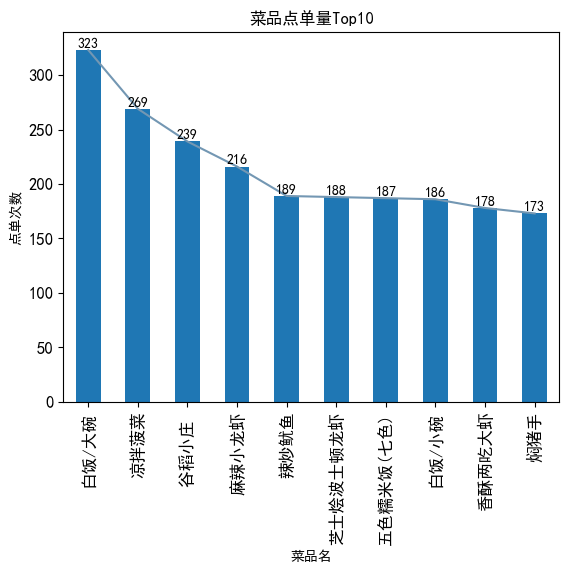

In [135]:
# 3.数据可视化matplotlib
dishes_count.plot(kind='line',color=['#7397B3'])
dishes_count.plot(kind='bar',fontsize=12)
for x,y in enumerate(dishes_count):
    plt.text(x,y+2,y,ha='center')
    plt.title('菜品点单量Top10',fontsize=12)
    plt.xlabel('菜品名')
    plt.ylabel('点单次数')

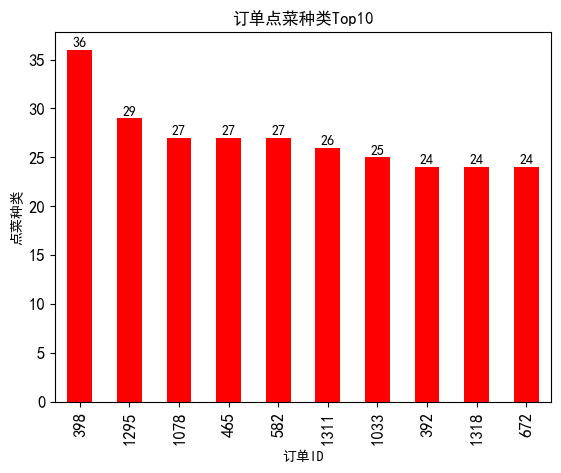

In [83]:
# 订单消费维度分析与可视化
# 订单点菜的种类最多
data_group = data['order_id'].value_counts()[:10]
data_group.plot(kind='bar',fontsize=12,color='r')
for x,y in enumerate(data_group):
    plt.text(x,y+0.3,y,ha='center')
    plt.title('订单点菜种类Top10')
    plt.xlabel('订单ID')
    plt.ylabel('点菜种类')

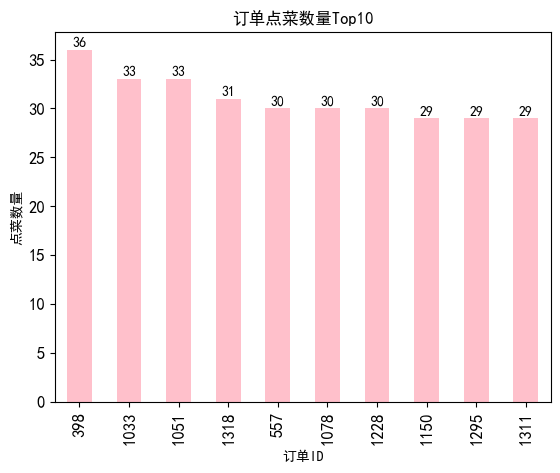

In [89]:
# 订单ID点菜数量最多
data['total_amounts'] = data['counts'] * data['amounts'] #统计单道菜消费总额
dataGroup = data[['order_id','counts','amounts','total_amounts']].groupby(by='order_id')
Group_sum = dataGroup.sum() #分组求和
sort_counts = Group_sum.sort_values(by='counts',ascending=False)
sort_counts['counts'][:10].plot(kind='bar',fontsize=12,color='#FFC0CB')
for x,y in enumerate(sort_counts['counts'][:10]):
    plt.text(x,y+0.3,y,ha='center')
    plt.title('订单点菜数量Top10')
    plt.xlabel('订单ID')
    plt.ylabel('点菜数量')

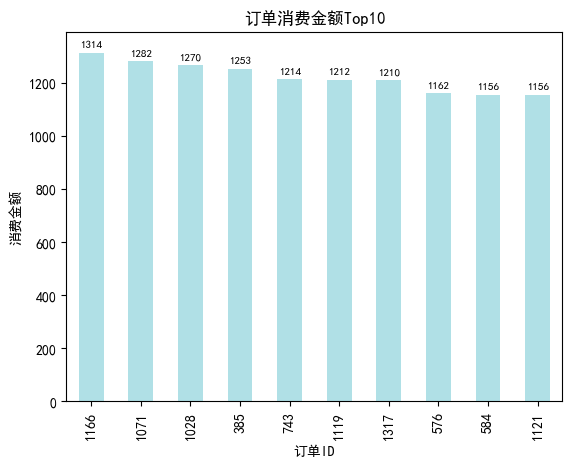

In [113]:
# 消费的最大金额
sort_total_amounts = Group_sum.sort_values(by='total_amounts',ascending=False)
sort_total_amounts['total_amounts'][:10].plot(kind='bar',color='#B0E0E6')
for x,y in enumerate(sort_total_amounts['total_amounts'][:10]):
    plt.ylim(0, max(sort_total_amounts['total_amounts'][:10]) + 80)
    plt.text(x,y+20,y,ha='center',fontsize=8)
    plt.title('订单消费金额Top10')
    plt.xlabel('订单ID')
    plt.ylabel('消费金额')

Text(0, 0.5, '消费单价')

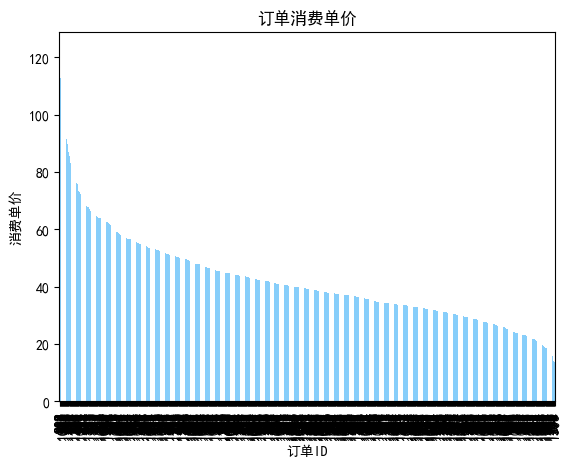

In [154]:
# 订单ID平均消费
Group_sum['average'] = Group_sum['total_amounts']/Group_sum['counts'].round(2)
sort_average = Group_sum.sort_values(by='average',ascending=False)
sort_average['average'][:].plot(kind='bar',color='#87CEFA')
plt.title('订单消费单价')
plt.xlabel('订单ID')
plt.ylabel('消费单价')

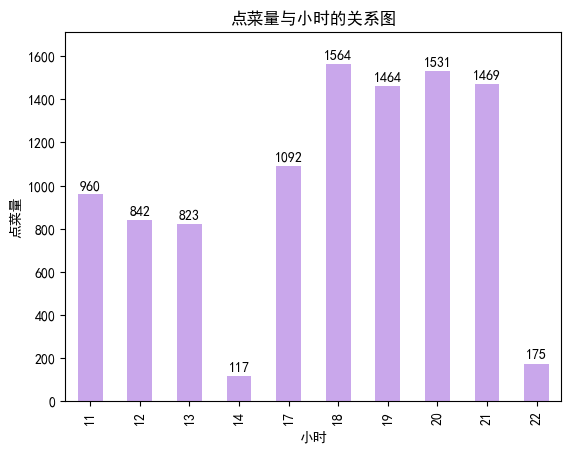

In [159]:
# 日期与时间维度进行点菜量分析
# 一天中哪个时间段订单量集中
data['hourcount']=1 #新列用作计数器
data['time'] = pd.to_datetime(data['place_order_time']) #将时间转换成日期类型存储
data['hour'] = data['time'].map(lambda x:x.hour) #解析出小时
group_by_hour = data.groupby(by='hour').count()['hourcount']
group_by_hour.plot(kind='bar',color='#C9A7EB')
for x,y in enumerate(group_by_hour):
    plt.ylim(0, max(group_by_hour)+150)
    plt.text(x,y+20,y,ha='center')
    plt.title('点菜量与小时的关系图')
    plt.xlabel('小时')
    plt.ylabel('点菜量')

Text(0, 0.5, '订单量')

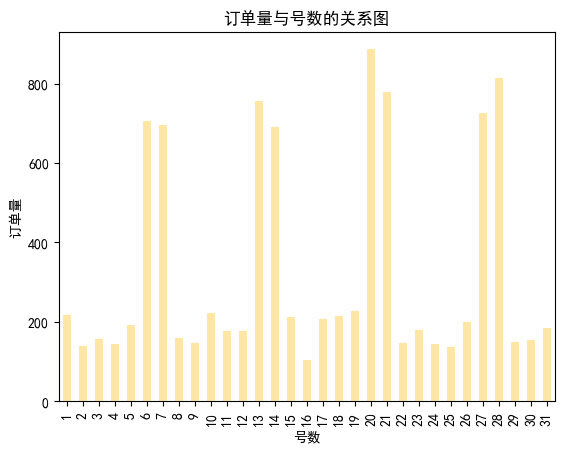

In [160]:
# 八月哪一天的订餐数量最多
data['daycount'] = 1
data['day'] = data['time'].map(lambda x:x.day) #解析出天
group_by_day = data.groupby(by='day').count()['daycount']
group_by_day.plot(kind='bar',color='#FFE6A5')
plt.title('订单量与号数的关系图')
plt.xlabel('号数')
plt.ylabel('订单量')

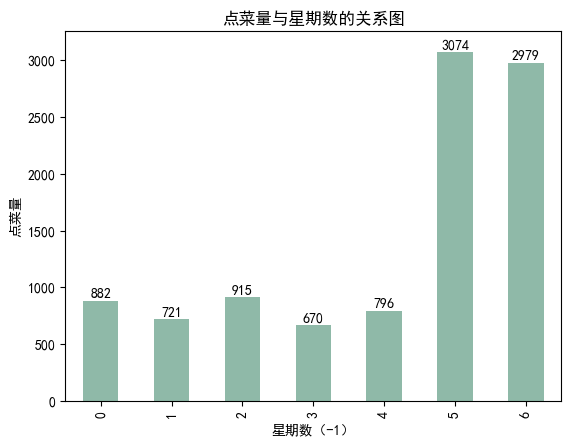

In [169]:
# 星期几人流量最大，订餐数最多，映射数据到星期
data['weekcount'] = 1
data['weekday'] = data['time'].map(lambda x:x.weekday())
group_by_weekday = data.groupby(by='weekday').count()['weekcount']
group_by_weekday.plot(kind='bar',color='#8FB9A8')
for x,y in enumerate(group_by_weekday):
    plt.ylim(0, max(group_by_weekday)+180)
    plt.text(x,y+25,y,ha='center')
    plt.title('点菜量与星期数的关系图')
    plt.xlabel('星期数（-1）')
    plt.ylabel('点菜量')